KeyboardInterrupt: 

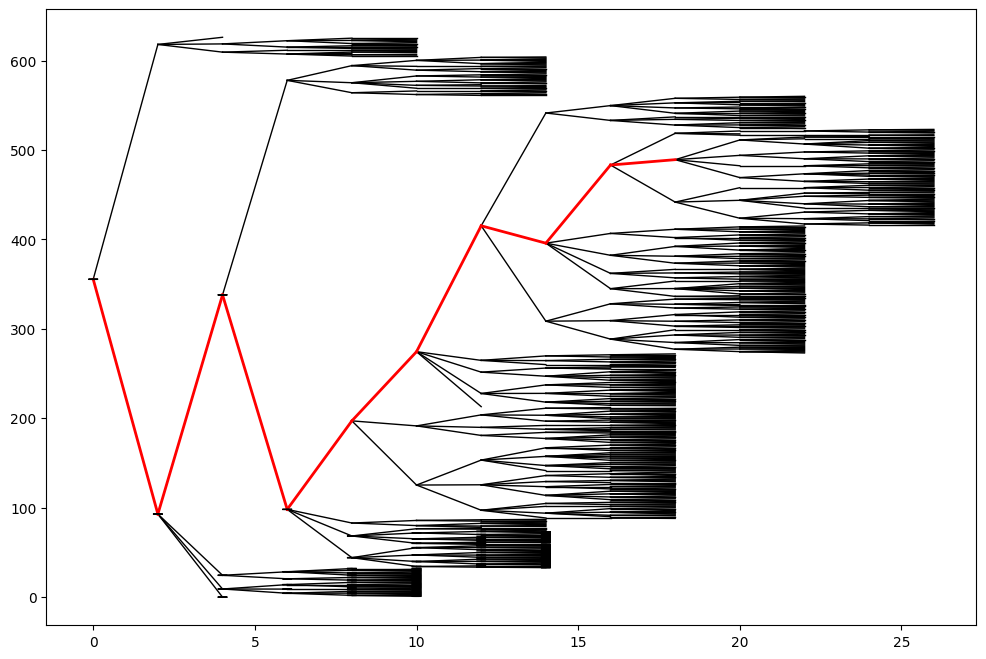

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio
import os
import shutil

# -----------------------
#    DATA STRUCTURES
# -----------------------

class Node:
    """
    A node in the global tree.
    """
    def __init__(self, token, prob=1.0, perplexity=40.0):
        self.token = token           # internal reference (not displayed)
        self.prob = prob             # probability (not displayed)
        self.perplexity = perplexity
        self.children = []           # list of Node
        self.parent = None           # Node
        self.selected = False        # whether this node has been selected
        # Coordinates for drawing
        self.x = 0
        self.y = 0

    def add_child(self, child_node):
        child_node.parent = self
        self.children.append(child_node)

# -----------------------
#   TREE GENERATION
# -----------------------

def generate_subtree(root, depth=5, candidate_count=5, p_cutoff=0.1, min_ppl=30, max_ppl=60):
    """
    Recursively generate up to 'depth' levels of children from 'root'
    (only if children have not already been generated).
    For each level, sample candidate_count probabilities (via a Dirichlet),
    keep those with probability >= p_cutoff and with a random perplexity in [min_ppl, max_ppl].
    """
    if depth == 0:
        return
    if root.children:
        return

    probs = np.random.dirichlet(np.ones(candidate_count))
    for p in probs:
        if p < p_cutoff:
            continue
        ppl = random.uniform(25, 65)
        if not (min_ppl <= ppl <= max_ppl):
            continue
        child = Node(token=f"{root.token}_child", prob=p, perplexity=ppl)
        root.add_child(child)
    for child in root.children:
        generate_subtree(child, depth=depth-1, candidate_count=candidate_count,
                         p_cutoff=p_cutoff, min_ppl=min_ppl, max_ppl=max_ppl)

def collect_branches(node, max_depth=5):
    """
    Collect all complete branches (paths) of length max_depth from the given node.
    """
    branches = []
    def dfs(current, path):
        path.append(current)
        if len(path) == max_depth + 1:
            branches.append(path[:])
            path.pop()
            return
        if not current.children:
            path.pop()
            return
        for child in current.children:
            dfs(child, path)
        path.pop()
    dfs(node, [])
    return branches

def pick_best_branch(branches):
    """
    Compute a random 'coherence' score for each branch, apply a softmax, and select the best.
    """
    if not branches:
        return None, None
    scores = [random.random() for _ in branches]
    exps = np.exp(scores)
    sm = exps / np.sum(exps)
    idx = int(np.argmax(sm))
    return branches[idx], sm[idx]

# -----------------------
#     TIDY LAYOUT
# -----------------------

def layout_tree_tidy(root, x_gap=2.0, y_gap=1.0):
    """
    Arrange the tree so that:
      - Each generation is placed at x = depth * x_gap.
      - Leaves are assigned sequential y coordinates (using a counter).
      - Internal nodes get their y as the average of their children.
    """
    counter = [0]  # mutable counter for y positions

    def _assign(node, depth):
        if not node.children:
            node.x = depth * x_gap
            node.y = counter[0] * y_gap
            counter[0] += 1
        else:
            for child in node.children:
                _assign(child, depth + 1)
            node.x = depth * x_gap
            child_ys = [child.y for child in node.children]
            node.y = np.mean(child_ys) if child_ys else 0

    _assign(root, 0)

def layout_entire_tree(root, x_start=0, y_gap=1.0, x_gap=2.0):
    """
    Re-layout the entire tree using the tidy layout.
    """
    layout_tree_tidy(root, x_gap=x_gap, y_gap=y_gap)

# -----------------------
#     DRAWING UTILITIES
# -----------------------

def get_bounding_box(root):
    """
    Traverse the tree to determine the bounding box (min_x, max_x, min_y, max_y).
    """
    min_x = max_x = root.x
    min_y = max_y = root.y
    def dfs(node):
        nonlocal min_x, max_x, min_y, max_y
        min_x = min(min_x, node.x)
        max_x = max(max_x, node.x)
        min_y = min(min_y, node.y)
        max_y = max(max_y, node.y)
        for child in node.children:
            dfs(child)
    dfs(root)
    return min_x, max_x, min_y, max_y

def collect_edges(root):
    """
    Gather edges into two lists: red edges (child.selected True) and black edges.
    Each edge is represented as (x1, y1, x2, y2).
    """
    black_edges = []
    red_edges = []
    def dfs(node):
        for child in node.children:
            if child.selected:
                red_edges.append((node.x, node.y, child.x, child.y))
            else:
                black_edges.append((node.x, node.y, child.x, child.y))
            dfs(child)
    dfs(root)
    return black_edges, red_edges

def collect_nodes(root):
    """
    Collect all nodes in the tree.
    """
    nodes = []
    def dfs(node):
        nodes.append(node)
        for child in node.children:
            dfs(child)
    dfs(root)
    return nodes

def draw_frame(root, iteration, filename):
    """
    Draw the tree with the following layering:
      1. Black edges (linewidth=1.0, zorder=1)
      2. Red edges (linewidth=2.0, zorder=2)
      3. Dots (zorder=3)
    Then set axis limits to include the entire tree and add the iteration title.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Collect edges and nodes
    black_edges, red_edges = collect_edges(root)
    nodes = collect_nodes(root)

    # Draw black edges (zorder=1)
    for (x1, y1, x2, y2) in black_edges:
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=1.0, zorder=1)
    # Draw red edges (zorder=2)
    for (x1, y1, x2, y2) in red_edges:
        ax.plot([x1, x2], [y1, y2], color='red', linewidth=2.0, zorder=2)
    # Draw the dots (zorder=3)
    for node in nodes:
        color = 'red' if node.selected else 'lightblue'
        dot = patches.Circle((node.x, node.y), radius=0.15,
                             edgecolor='black', facecolor=color, zorder=3)
        ax.add_patch(dot)

    ax.set_title(f"Iteration {iteration}")
    ax.set_aspect('equal', 'box')
    ax.axis('off')

    # Adjust axis limits to include entire tree with margin
    min_x, max_x, min_y, max_y = get_bounding_box(root)
    margin = 1.0
    ax.set_xlim(min_x - margin, max_x + margin)
    ax.set_ylim(min_y - margin, max_y + margin)

    plt.savefig(filename, bbox_inches='tight')
    plt.close(fig)

# -----------------------
#   MAIN SIMULATION LOOP
# -----------------------

def main():
    random.seed(42)
    np.random.seed(42)

    # Prepare frames directory
    frames_dir = "branch_frames"
    if os.path.exists(frames_dir):
        shutil.rmtree(frames_dir)
    os.makedirs(frames_dir)

    # Initialize the root node
    root = Node(token="Once_upon_a_time", prob=1.0, perplexity=40.0)
    root.selected = True
    current_node = root

    frame_files = []
    num_iterations = 50

    for iteration in range(1, num_iterations + 1):
        # Expand current node if needed
        if not current_node.children:
            generate_subtree(current_node, depth=5, candidate_count=5)

        # Collect branches from current node
        branches = collect_branches(current_node, max_depth=5)

        # If no branch exists, add a fallback child
        if not branches:
            fallback = Node(token=f"fallback_{iteration}", prob=1.0, perplexity=40.0)
            current_node.add_child(fallback)
            fallback.selected = True
            current_node = fallback
        else:
            best_branch, score = pick_best_branch(branches)
            if best_branch is None:
                fallback = Node(token=f"fallback_{iteration}", prob=1.0, perplexity=40.0)
                current_node.add_child(fallback)
                fallback.selected = True
                current_node = fallback
            else:
                # Choose the immediate child in the best branch
                chosen_node = best_branch[1]
                chosen_node.selected = True
                current_node = chosen_node

        # Layout the entire tree using the tidy layout algorithm
        layout_entire_tree(root, x_gap=2.0, y_gap=1.0)

        # Draw and save the current frame
        frame_filename = os.path.join(frames_dir, f"frame_{iteration:03d}.png")
        draw_frame(root, iteration, frame_filename)
        frame_files.append(frame_filename)

    # Create the final GIF
    gif_filename = "branching_simulation.gif"
    with imageio.get_writer(gif_filename, mode='I', duration=1.0) as writer:
        for fname in frame_files:
            image = imageio.imread(fname)
            writer.append_data(image)

    print(f"GIF saved as {gif_filename}")

if __name__ == "__main__":
    main()
